# Statistics for Problem transformation experiments

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score

#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [ini_results_filepath, nnrti_results_filepath, nrti_results_filepath, pi_results_filepath]




#setting filepaths for the benchmarking datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [ini_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, pi_results_filepath_ml]


## Binary relevance with TabPFN predicts labels on par with state of the art

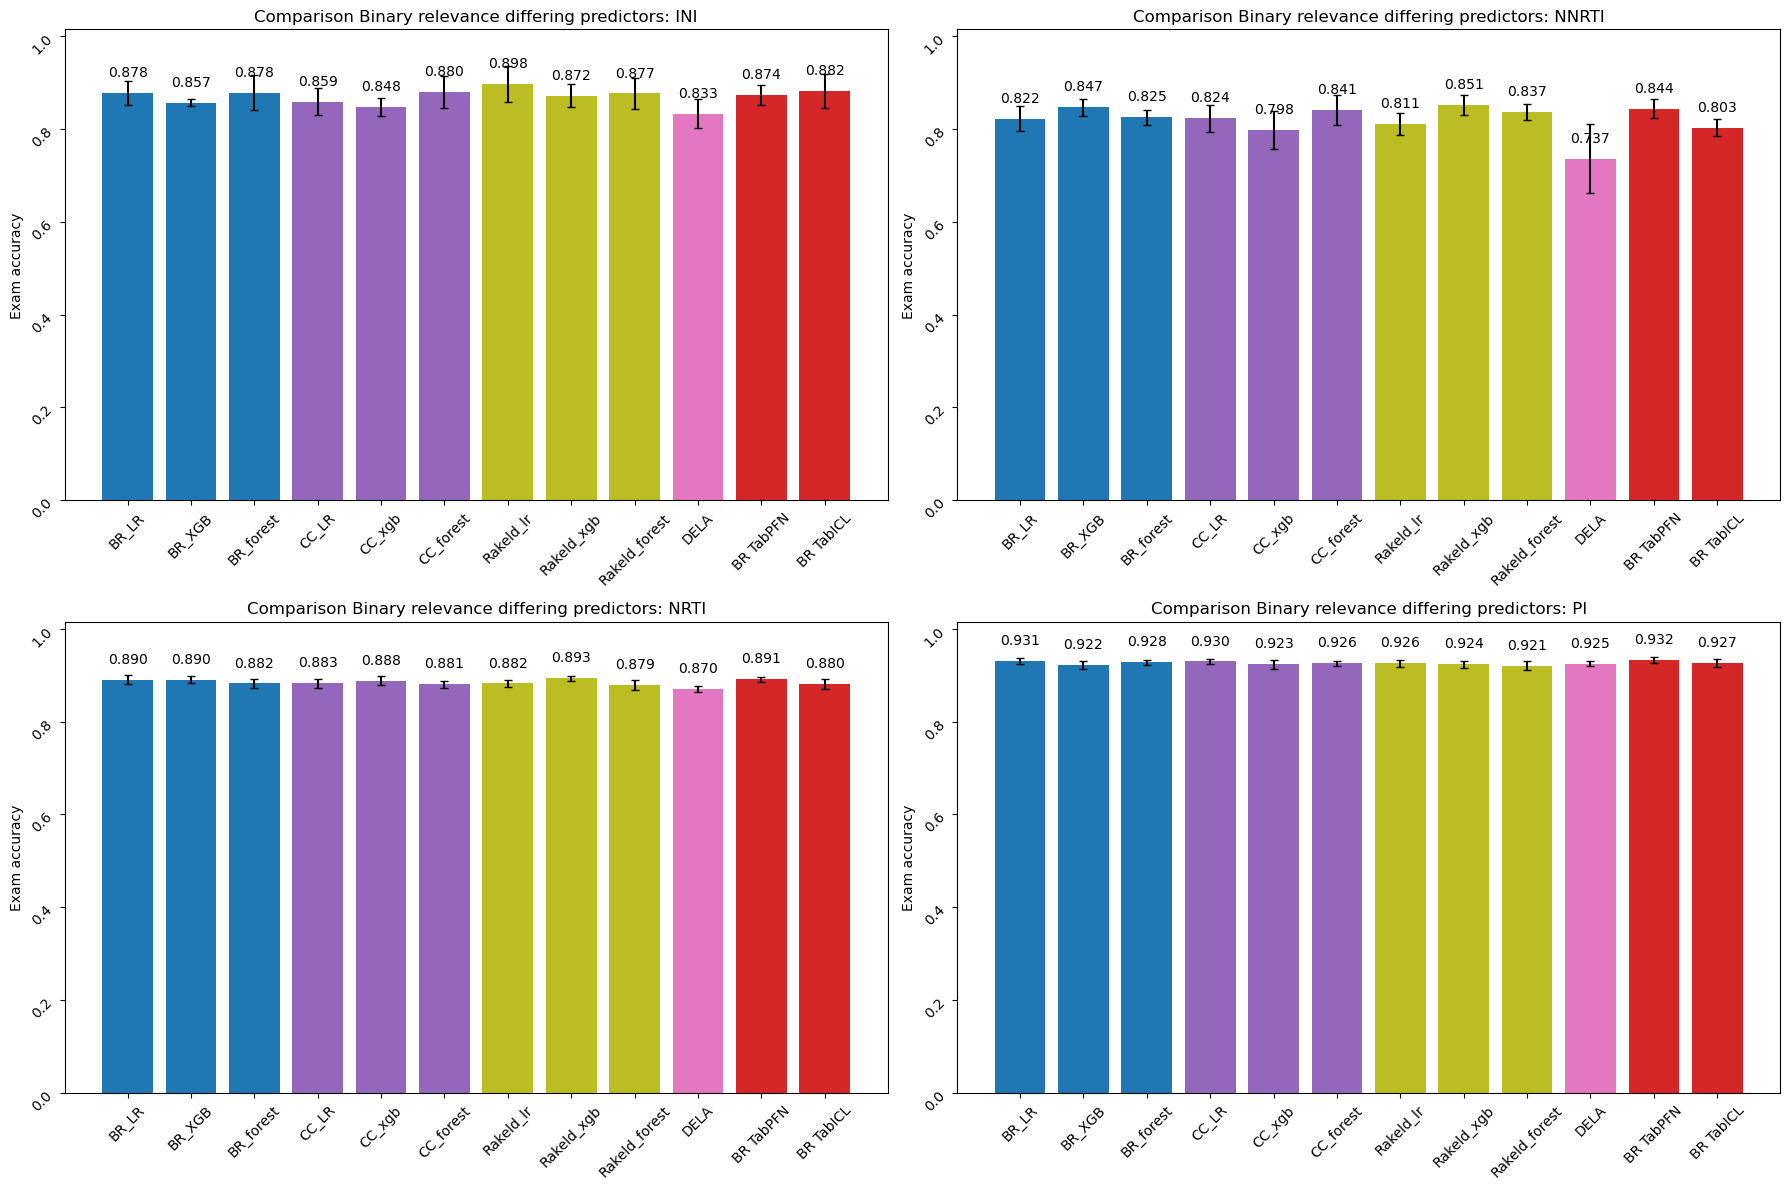

In [3]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

ending = "_5_fold.csv"

sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

[sub_accs_fold_mean[x].extend(tmp_sub_accs_fold_mean[x]) for x in sub_accs_fold_mean.keys()]
[sub_accs_fold_std[x].extend(tmp_sub_accs_fold_std[x]) for x in sub_accs_fold_std.keys()]


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "BR TabICL"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models  + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
plt.show()

#plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_exam_acc.png")


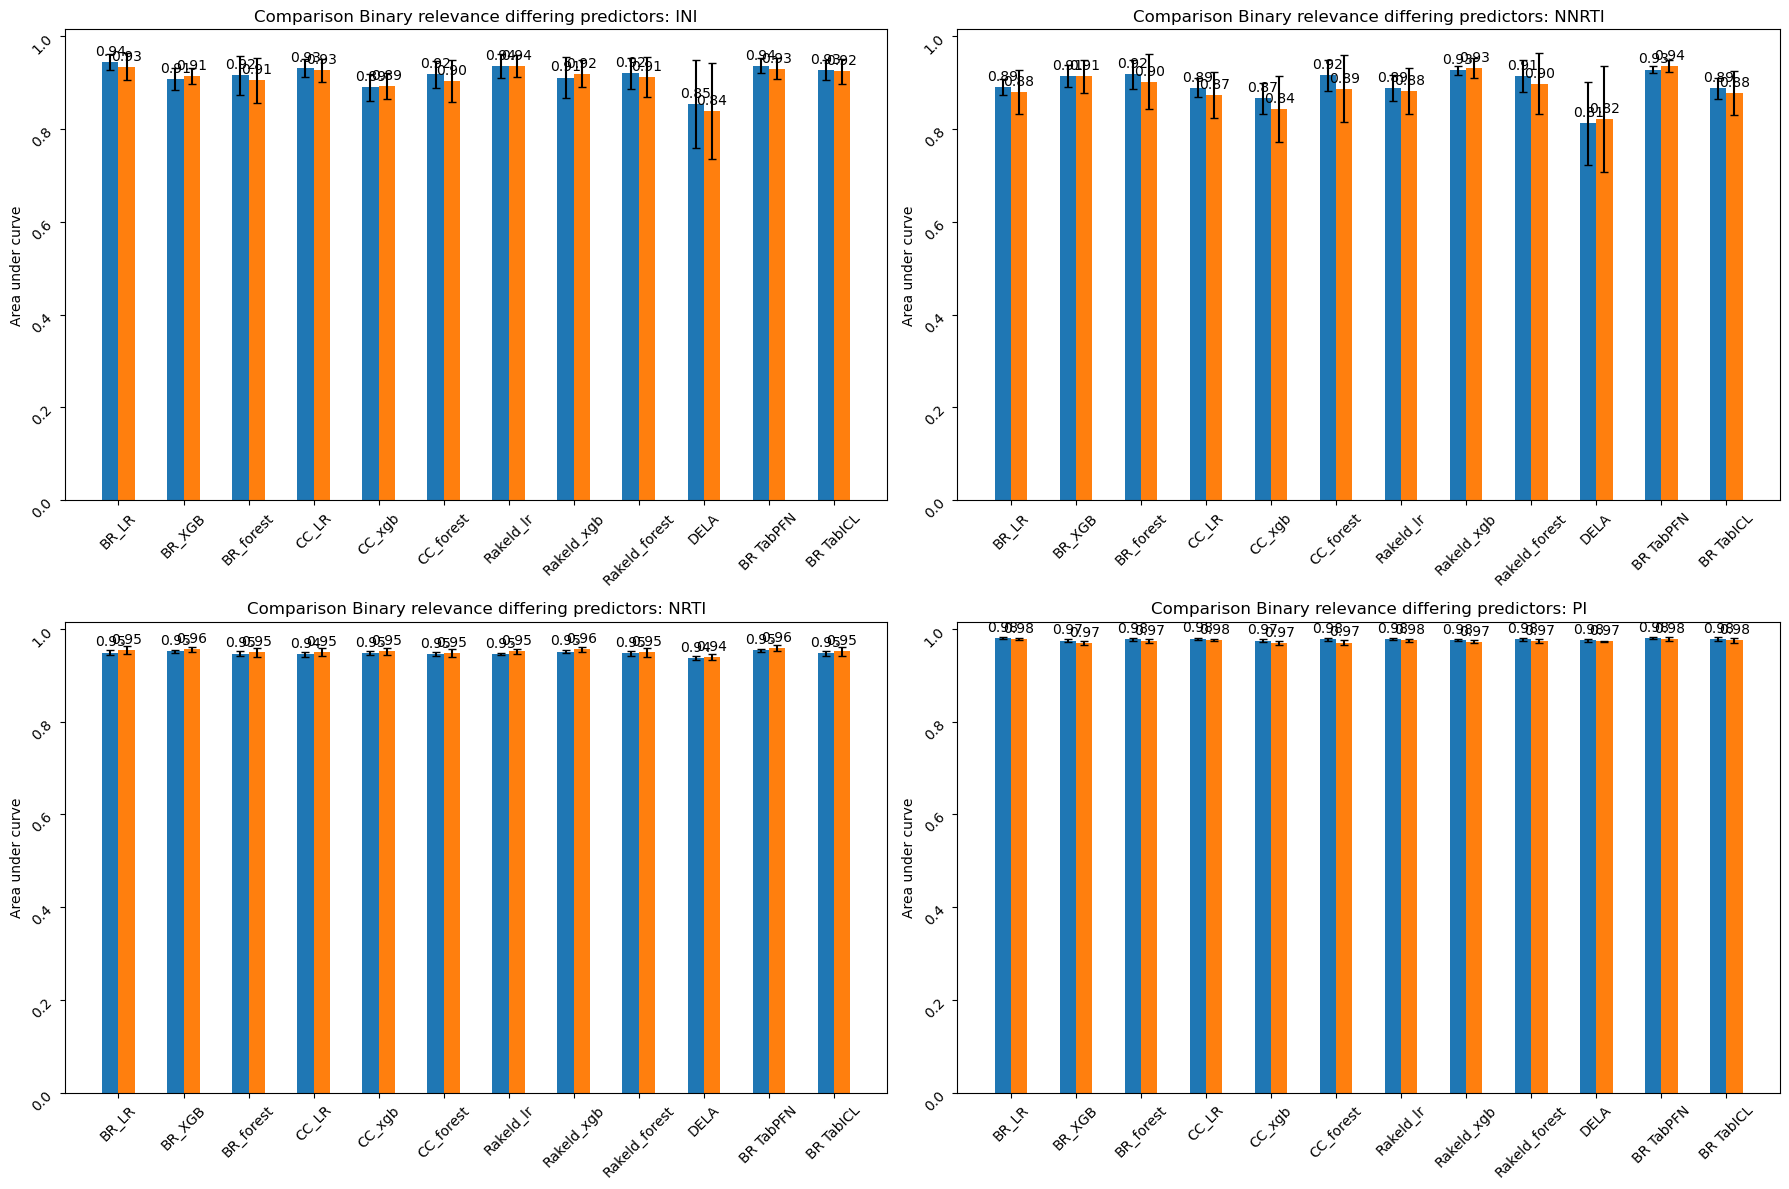

In [31]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

ending = "_5_fold_probabilities.csv"

roc_auc_mean, roc_auc_std = result_handler.calc_metrics(filepath_list_ml, ml_models, roc_auc_score, {"average": "macro"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

[roc_auc_mean[x].extend(tmp_roc_auc_mean[x]) for x in roc_auc_mean.keys()]
[roc_auc_std[x].extend(tmp_roc_auc_std[x]) for x in roc_auc_std.keys()]


df_roc_auc_mean = pd.DataFrame(roc_auc_mean)
df_roc_auc_std = pd.DataFrame(roc_auc_std)

prc_auc_mean, prc_auc_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.prc_auc_score, {"multiclass":"ovr"}, ending=ending, drop_na=False)


tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovr"}, drop_na=True)

[prc_auc_mean[x].extend(tmp_prc_auc_mean[x]) for x in prc_auc_mean.keys()]
[prc_auc_std[x].extend(tmp_prc_auc_std[x]) for x in prc_auc_std.keys()]


df_prc_auc_mean = pd.DataFrame(prc_auc_mean)
df_prc_auc_std = pd.DataFrame(prc_auc_std)


models_w_TabPFN = ["BR TabPFN", "BR TabICL"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

labels = ml_models  + models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):


    multiplier = -0.5

    offset = width * multiplier
    rects = axs[i].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC")
    axs[i].bar_label(rects, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[i].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC")
    axs[i].bar_label(rects2, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    axs[i].set_xticks(x)
    axs[i].set_xticklabels(labels)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Area under curve')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()

#plt.show()

plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_ROC_prc_auc.png")


## Classifier Chains improve predictive results compared to binary relevance

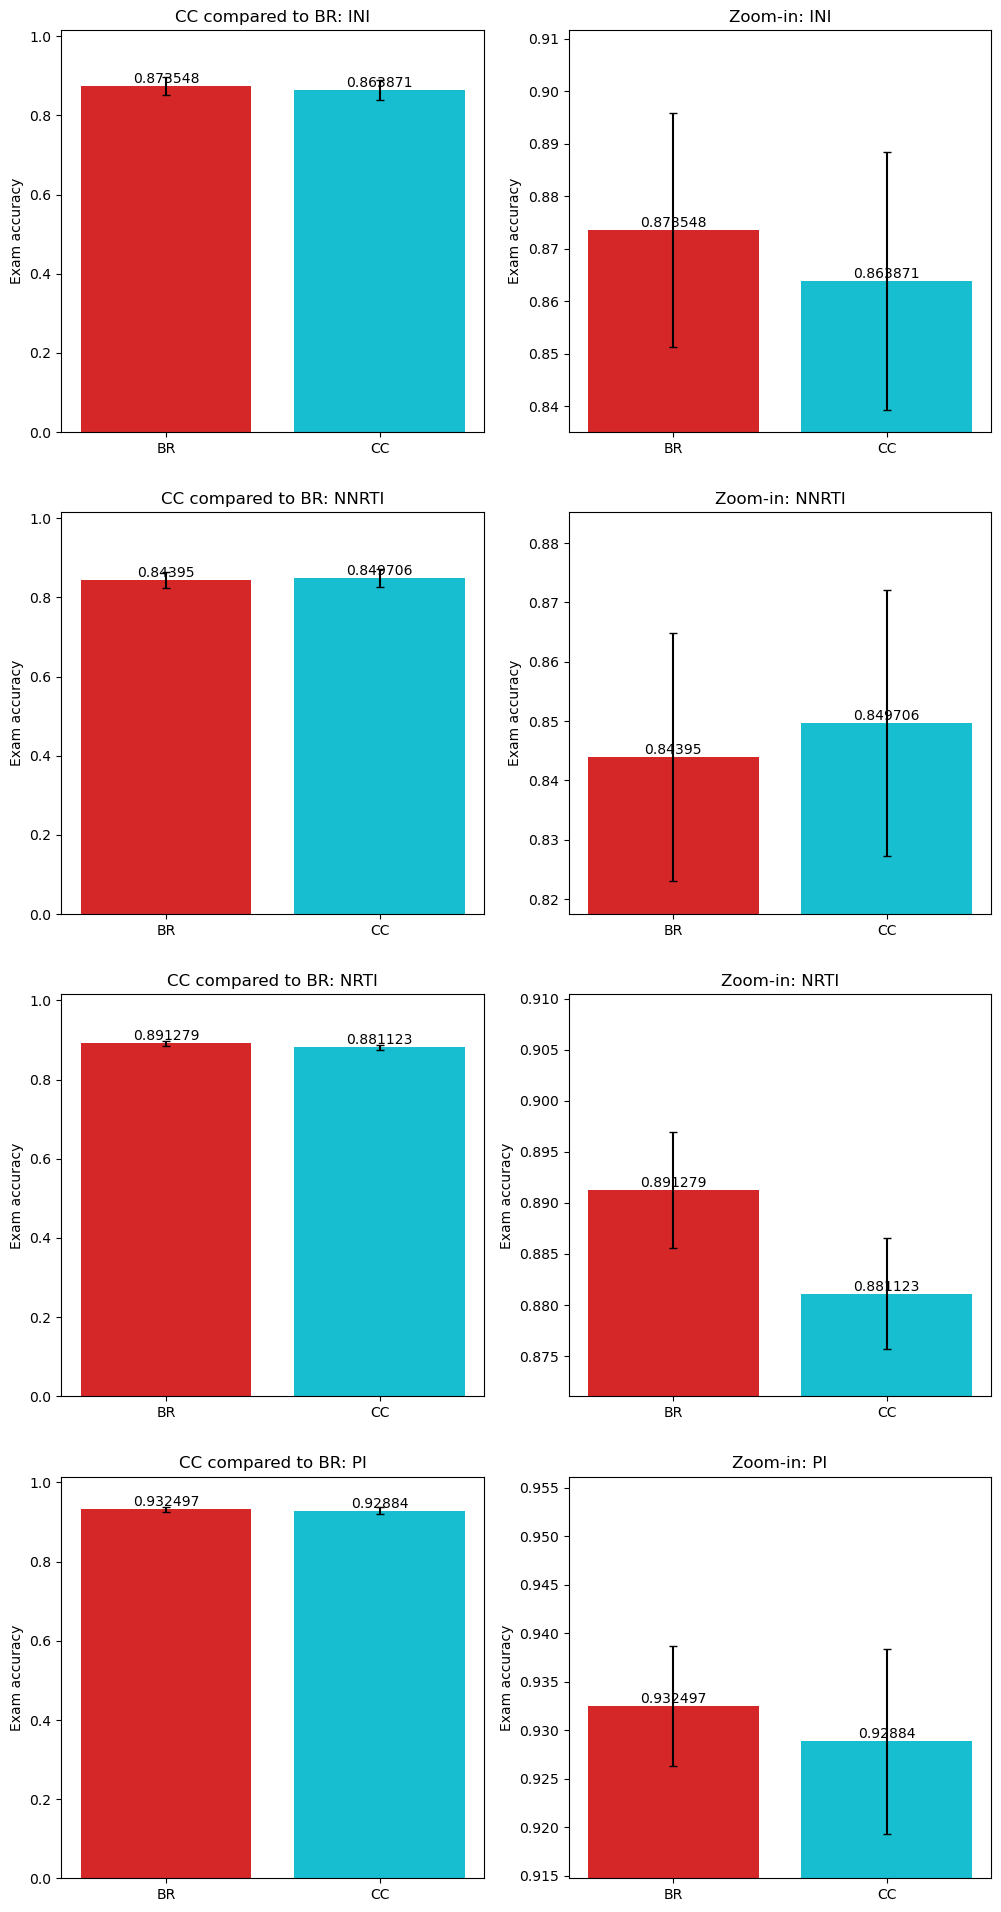

In [21]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR", "CC"]

color = ["tab:red"] + ["tab:cyan"]

fig, axs = plt.subplots(4, 2, figsize=(12, 24))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    j = i * 2

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Exam accuracy')
    axs[j].set_ylim(0, 1.015)
    axs[j].set_title('CC compared to BR: ' + drug)

    p2 = axs[j +1].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j +1].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j +1].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j +1].set_ylabel('Exam accuracy')
    axs[j+1].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[j +1].set_title('Zoom-in: ' + drug)


#plt.savefig("../figures/03_CC_better_BR/CC_better_exam_acc.png")



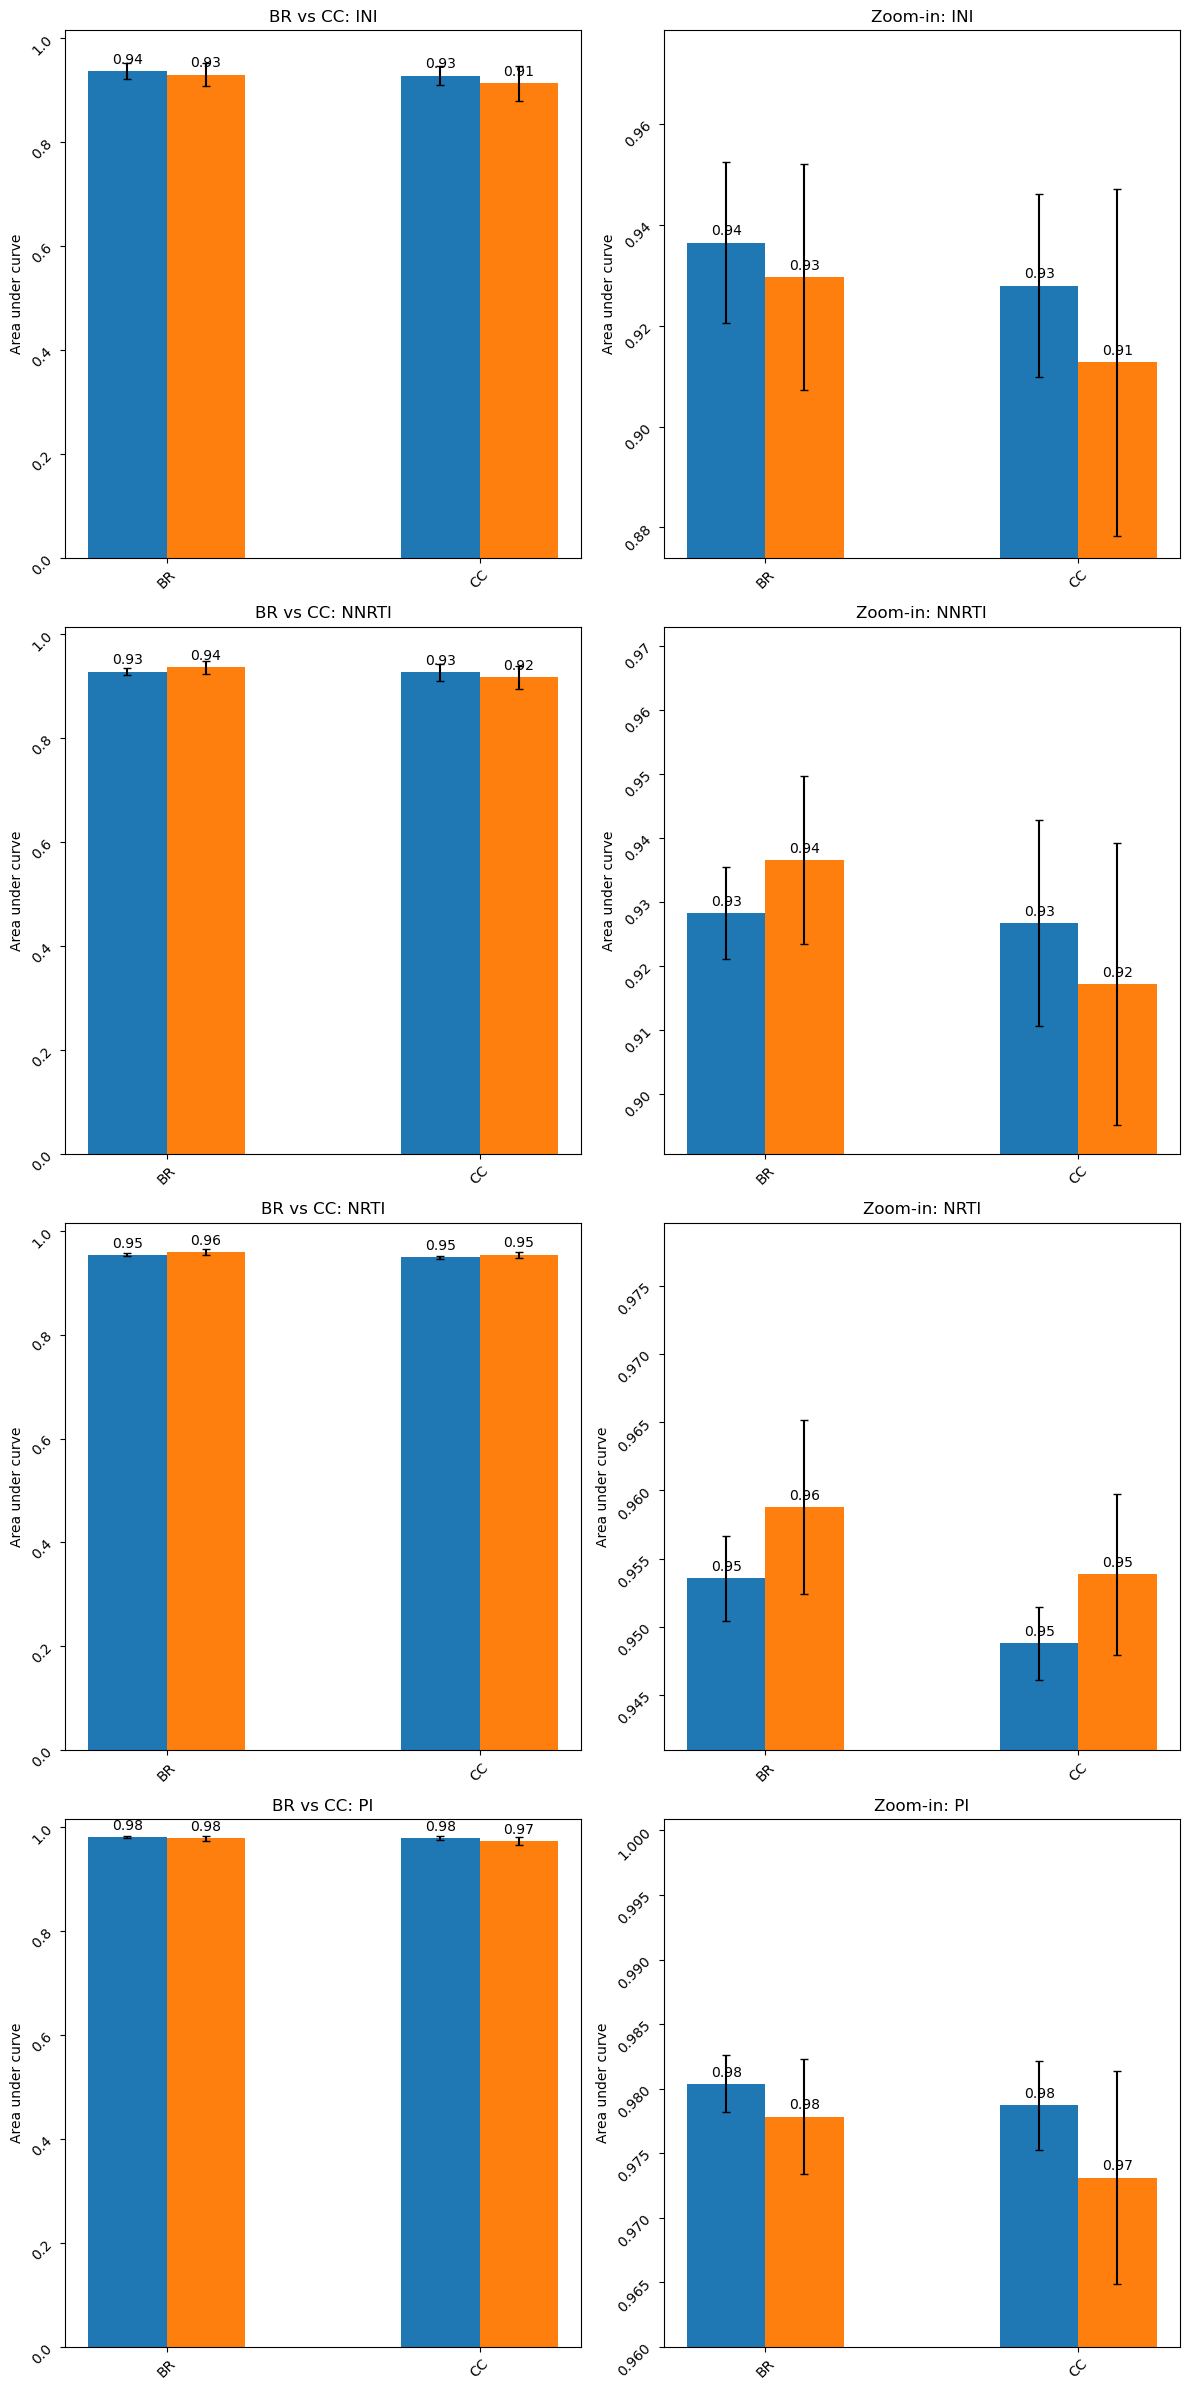

In [20]:

files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovr"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)


models_w_TabPFN = ["BR", "CC"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, axs = plt.subplots(4, 2, figsize=(12, 24))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):

    j = i * 2

    multiplier = -0.5

    offset = width * multiplier
    rects = axs[j].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC")
    axs[j].bar_label(rects, fmt='%.2f', padding=3)
    axs[j].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[j].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC")
    axs[j].bar_label(rects2, fmt='%.2f', padding=3)
    axs[j].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    axs[j].set_xticks(x)
    axs[j].set_xticklabels(models_w_TabPFN)
    axs[j].tick_params(rotation=45)
    axs[j].set_ylabel('Area under curve')
    axs[j].set_ylim(0, 1.0  * 1.015)
    axs[j].set_title('BR vs CC: ' + drug)

    multiplier = -0.5

    offset = width * multiplier
    rects = axs[j + 1].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC")
    axs[j + 1].bar_label(rects, fmt='%.2f', padding=3)
    axs[j + 1].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[j + 1].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC")
    axs[j + 1].bar_label(rects2, fmt='%.2f', padding=3)
    axs[j + 1].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    axs[j + 1].set_xticks(x)
    axs[j + 1].set_xticklabels(models_w_TabPFN)
    axs[j + 1].tick_params(rotation=45)
    axs[j + 1].set_ylabel('Area under curve')
    axs[j+1].set_ylim(max(0, min((df_roc_auc_mean[drug].min() - df_roc_auc_std[drug].max()) * 0.995, (df_prc_auc_mean[drug].min() - df_prc_auc_std[drug].max()) * 0.995)), min(max((1.0 + df_roc_auc_std[drug].max()) * 1.015, (1.0 + df_prc_auc_std[drug].max()) * 1.015), max((df_roc_auc_mean[drug].max() + df_roc_auc_std[drug].max())  * 1.015, (df_prc_auc_mean[drug].max() + df_prc_auc_std[drug].max())  * 1.015)))
    axs[j + 1].set_title('Zoom-in: ' + drug)

fig.tight_layout()

#plt.show()

#plt.savefig("../figures/03_Incl_NaN/Incl_NaN_AUC.png")


## Inclusion of targets with missing values improves predictive power

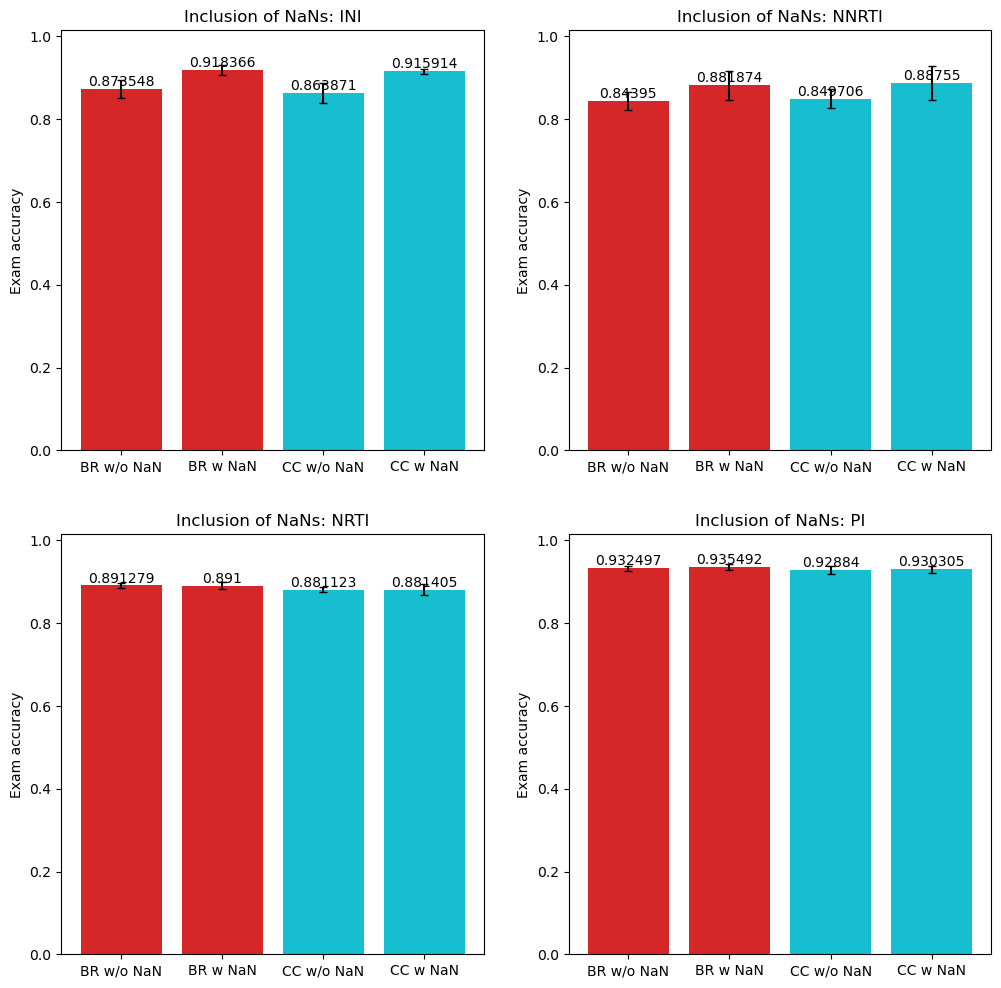

In [15]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.015)
    axs[i].set_title('Inclusion of NaNs: ' + drug)


plt.savefig("../figures/04_Incl_NaN/Incl_NaN_Exam_Acc.png")



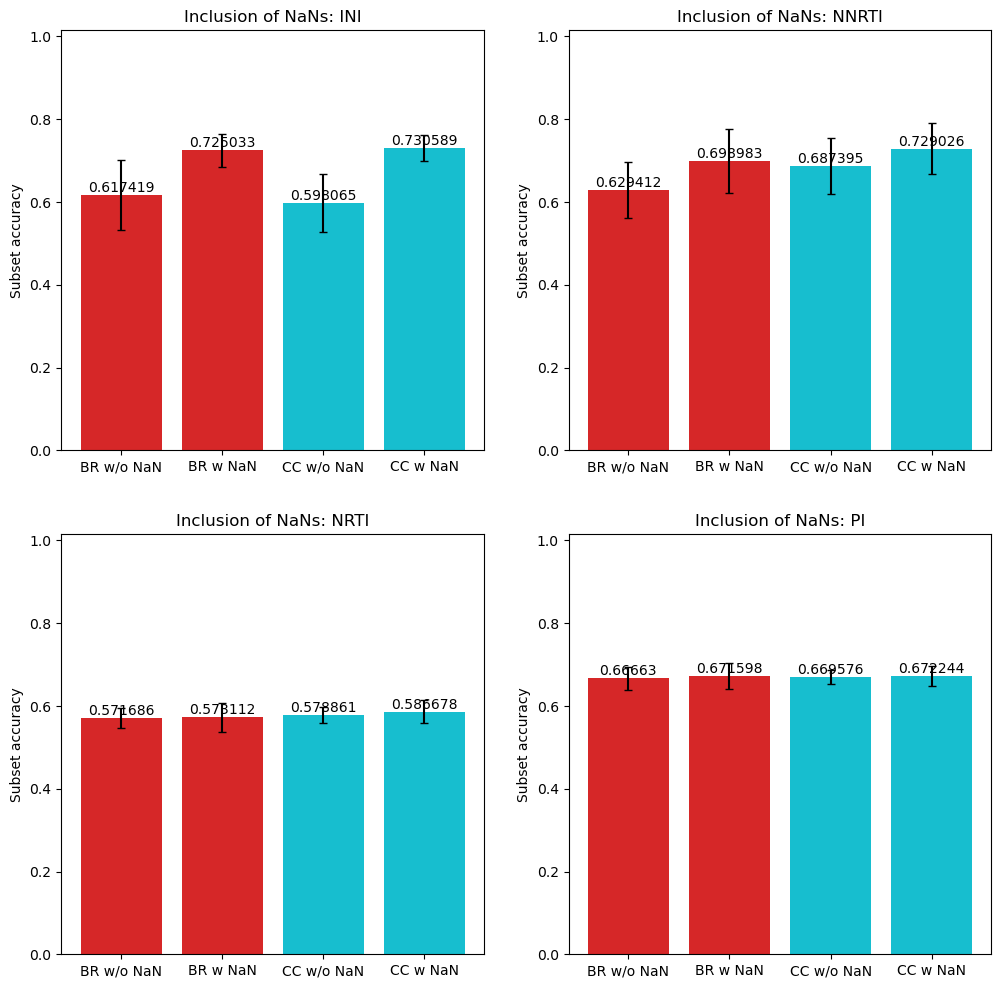

In [32]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.subset_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(0, 1.015)
    axs[i].set_title('Inclusion of NaNs: ' + drug)



plt.show()
#plt.savefig("../figures/04_Incl_NaN/Incl_NaN_Exam_Acc.png")



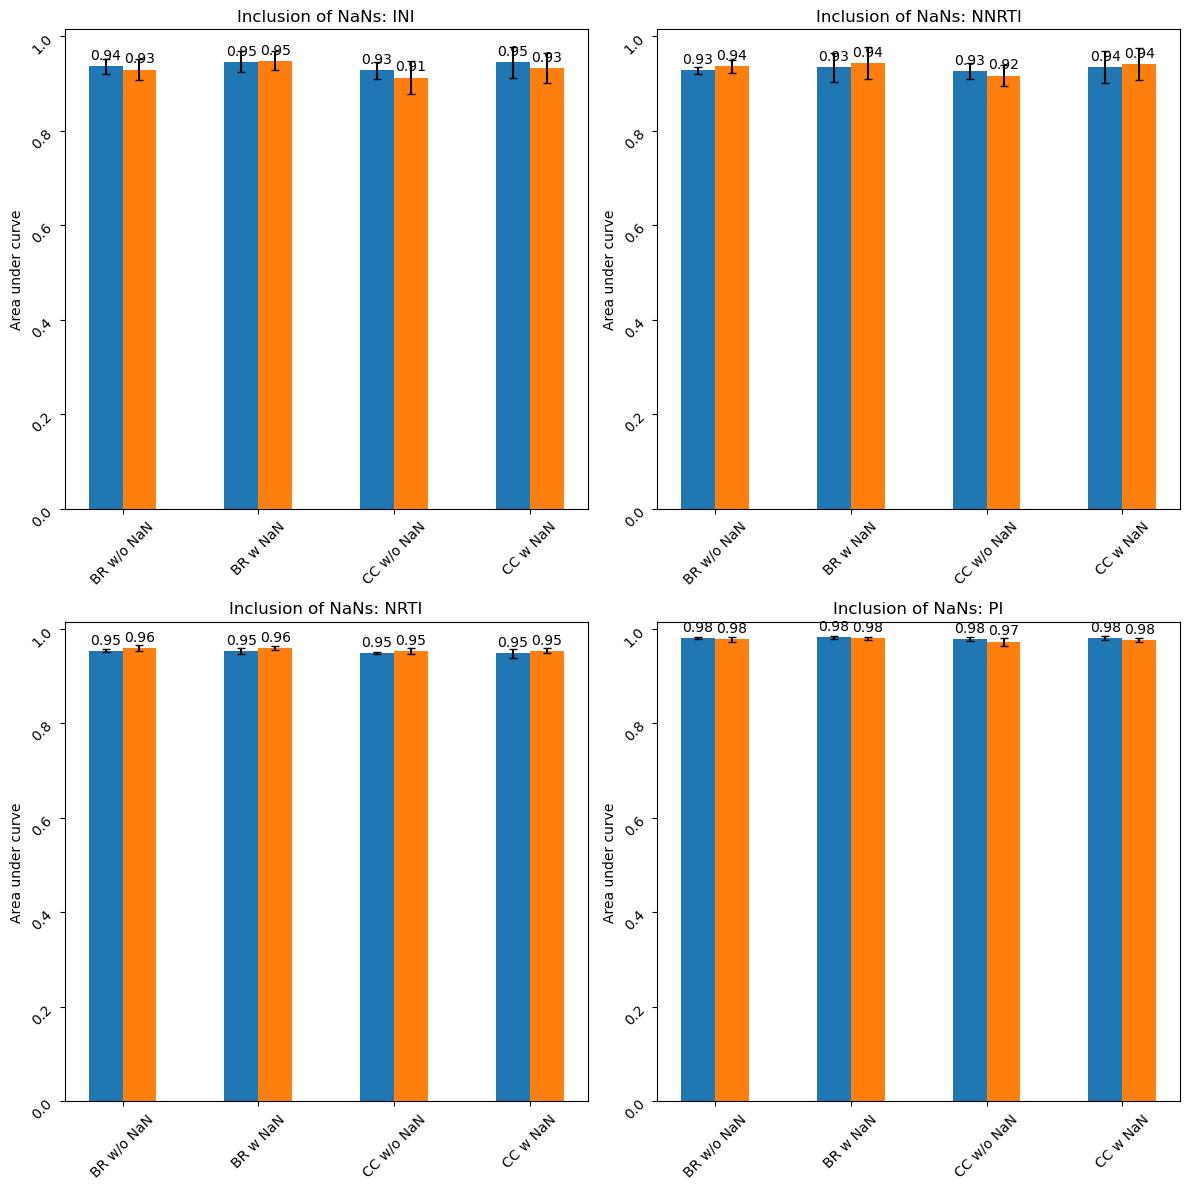

In [21]:

files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovr"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):


    multiplier = -0.5

    offset = width * multiplier
    rects = axs[i].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC")
    axs[i].bar_label(rects, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[i].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC")
    axs[i].bar_label(rects2, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    axs[i].set_xticks(x)
    axs[i].set_xticklabels(models_w_TabPFN)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Area under curve')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Inclusion of NaNs: ' + drug)

fig.tight_layout()

#plt.show()

#plt.savefig("../figures/04_Incl_NaN/Incl_NaN_AUC.png")


## CC ensembles do not improve the results

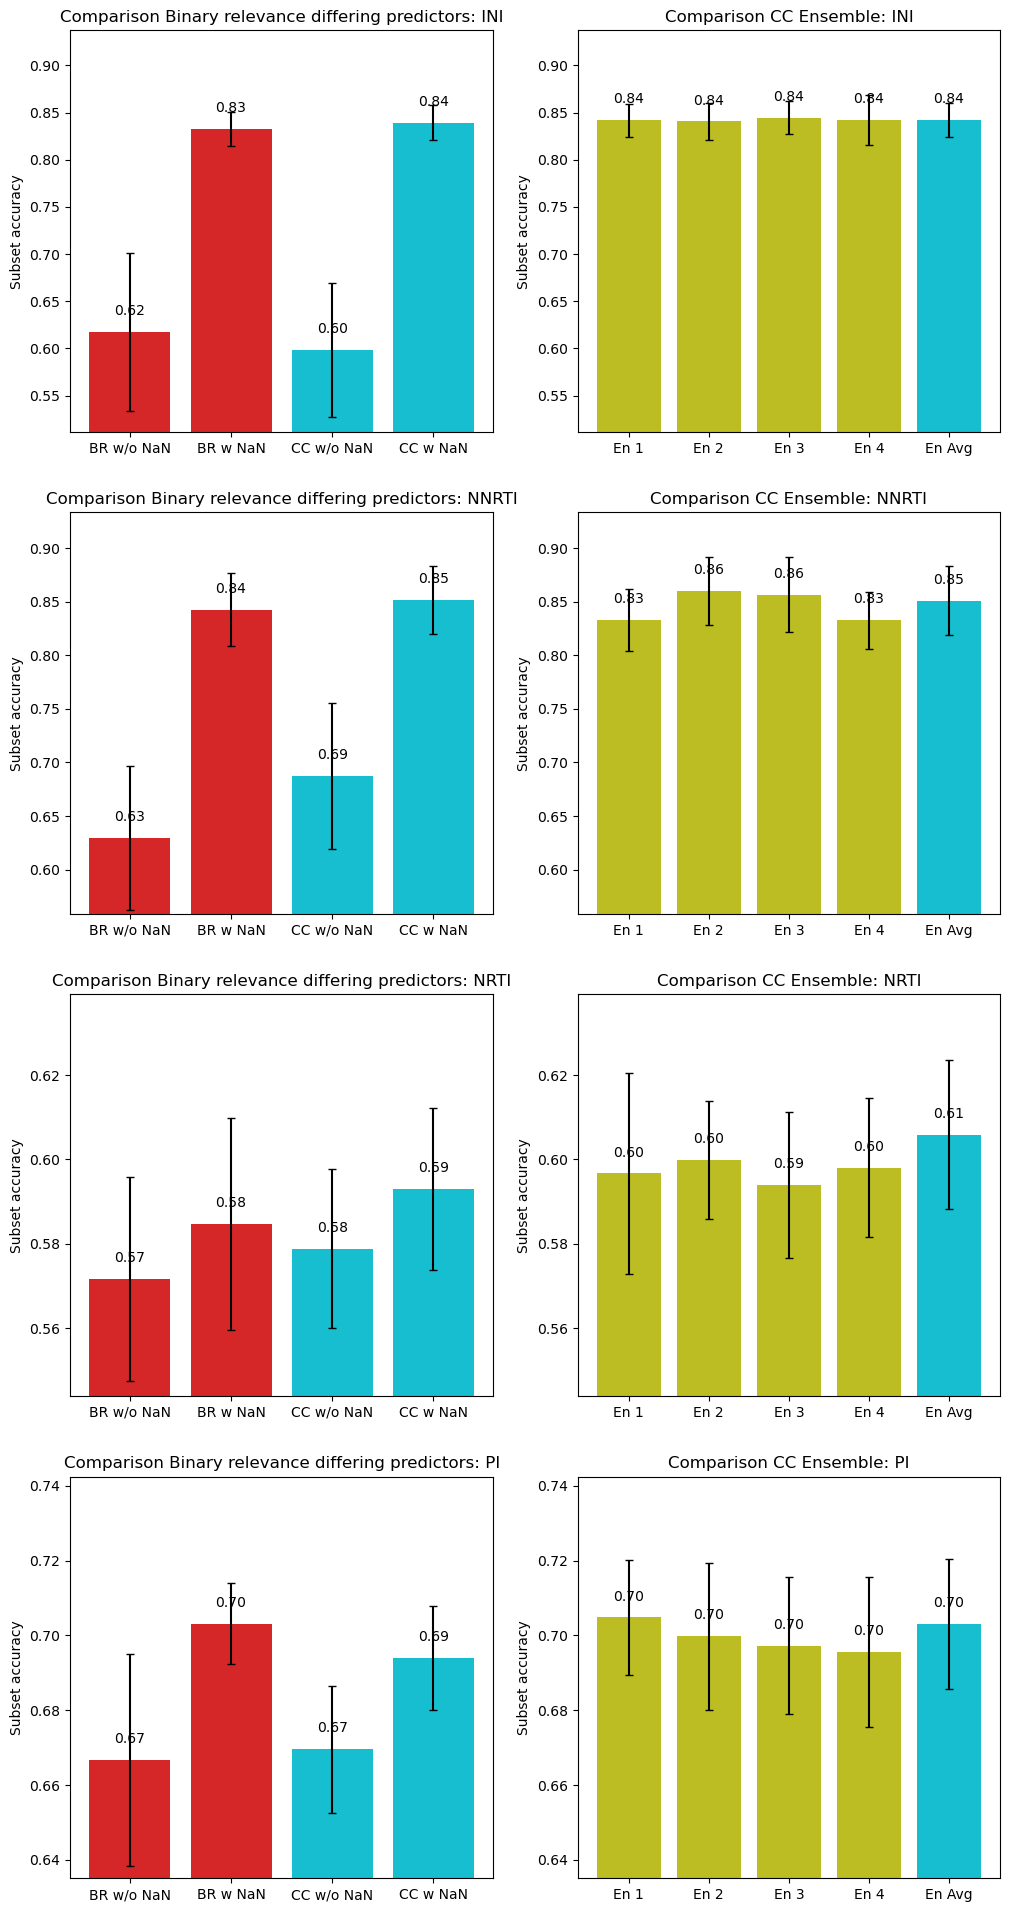

In [17]:

def cc_ensemble_stat(files, filename, drop_na, metric, kwargs):
    tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na)

    df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
    df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

    ensemble_accs_mean = {}
    ensemble_accs_std = {}

    for path in filepath_list:

        chains = os.listdir(path + filename)

        chain_list = []
        chain_acc_list_mean = []
        chain_acc_list_std = []

        true_labels = None

        for chain in chains:
            #print(path+filename+chain)

            results = pd.read_csv(path + filename + chain)

            #print(path+filename+chain)

            if drop_na:
                results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

            pred_labels = results.filter(regex="Pred_*")

            true_labels = results.filter(regex="True_*")
            #pred_labels = (pred_probas > 0.5) * 1.0

            subs_accs_groups = results.groupby(by="kFolds").apply(
                lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
                include_groups=False)

            #print(true_labels == true_labels_old)
            #print(pred_labels == pred_labels_old)

            chain_list.append(pred_labels)

            chain_acc_list_mean.append(subs_accs_groups.mean())
            chain_acc_list_std.append(subs_accs_groups.std())
            #chain_acc_list.append(sub_acc)

        #chain_list = np.array(chain_list)

        columns = chain_list[0].columns.values.tolist()

        ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

        ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

        #print(ave_chain_df.shape)
        kfold = results["kFolds"]

        true_labels.reset_index(drop=True, inplace=True)
        ave_chain_df.reset_index(drop=True, inplace=True)
        kfold.reset_index(drop=True, inplace=True)

        ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)



        #true_labels = ave_chain_df.filter(regex="True_*")
        #pred_labels = (ave_chain_df > 0.5) * 1.0

        #print(ave_chain_complete)

        subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)

        #sub_acc = result_handler.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        chain_acc_list_mean.append(subs_accs_groups.mean())
        chain_acc_list_std.append(subs_accs_groups.std())
        #chain_acc_list.append(sub_acc)

        ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})
        ensemble_accs_std.update({path.split("/")[-1].strip("_"): chain_acc_list_std})



    df_ensemble_accs_groups_mean = pd.DataFrame(ensemble_accs_mean)
    df_ensemble_accs_groups_std = pd.DataFrame(ensemble_accs_std)





    #Figure


    models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

    color = ["tab:red"] * 2 + ["tab:cyan"] * 2

    ensemble_labels = ["En 1", "En 2", "En 3", "En 4", "En Avg"]

    color_en = ["tab:olive"] * 4 + ["tab:cyan"]

    fig, axs = plt.subplots(4, 2, figsize=(12, 24))

    axs = axs.flatten()

    for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):
        j = 2 * i
        #print(axs[i])
        #print(i)

        p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
        axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug], capsize=3,
                        fmt="none", ecolor="black")

        axs[j].bar_label(p, fmt='%.2f', label_type="edge", padding=10)

        #axs[i].set_xticks(x)
        #axs[i].set_xticklabels(target_ml["Drug"])
        axs[j].set_ylabel('Subset accuracy')
        axs[j].set_ylim(max(0, min((df_ensemble_accs_groups_mean[drug].min() - df_ensemble_accs_groups_std[drug].max()),
                                   (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max())) * 0.995),
                        min(1.0 + df_ensemble_accs_groups_std[drug].max(),
                            max((df_ensemble_accs_groups_mean[drug].max() + df_ensemble_accs_groups_std[drug].max()),
                                (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())) * 1.015))
        axs[j].set_title('Comparison Binary relevance differing predictors: ' + drug)

        p2 = axs[j + 1].bar(ensemble_labels, df_ensemble_accs_groups_mean[drug], color=color_en)
        axs[j + 1].errorbar(ensemble_labels, df_ensemble_accs_groups_mean[drug], yerr=df_ensemble_accs_groups_std[drug],
                            capsize=3, fmt="none", ecolor="black")

        axs[j + 1].bar_label(p2, fmt='%.3f', label_type="edge", padding=10)

        #axs[i].set_xticks(x)
        #axs[i].set_xticklabels(target_ml["Drug"])
        axs[j + 1].set_ylabel('Subset accuracy')
        axs[j + 1].set_ylim(max(0, min((df_ensemble_accs_groups_mean[drug].min() - df_ensemble_accs_groups_std[drug].max()),
                                       (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max())) * 0.995),
                            min(1.0 + df_ensemble_accs_groups_std[drug].max(),
                                max((df_ensemble_accs_groups_mean[drug].max() + df_ensemble_accs_groups_std[drug].max()),
                                    (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())) * 1.015))
        axs[j + 1].set_title('Comparison CC Ensemble: ' + drug)

    #plt.savefig("../figures/BR_CC_ensemble_kfold_comparison_own_save.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")

files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble/"

drop_na = False
metric = result_handler.subset_acc
kwargs = {"nan_mode":"ignore"}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)


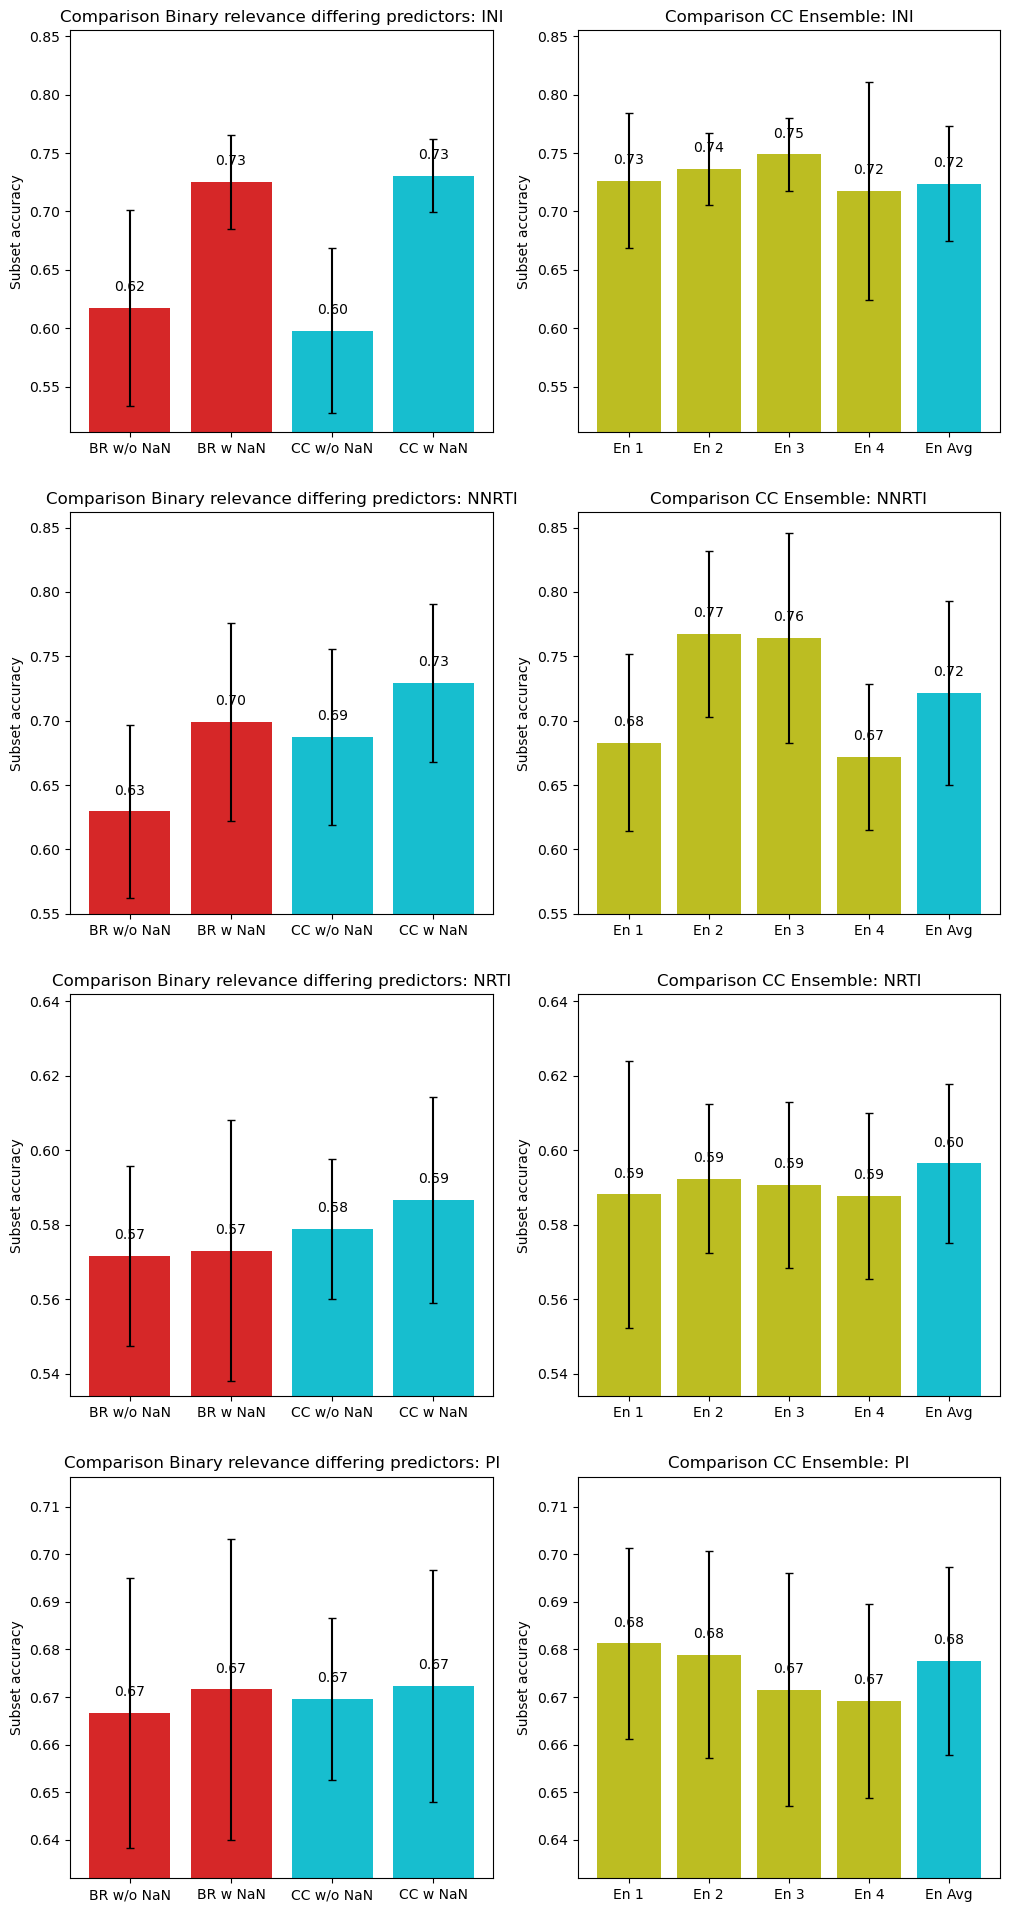

In [18]:
drop_na = True
metric = result_handler.subset_acc
kwargs = {"nan_mode":"ignore"}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)

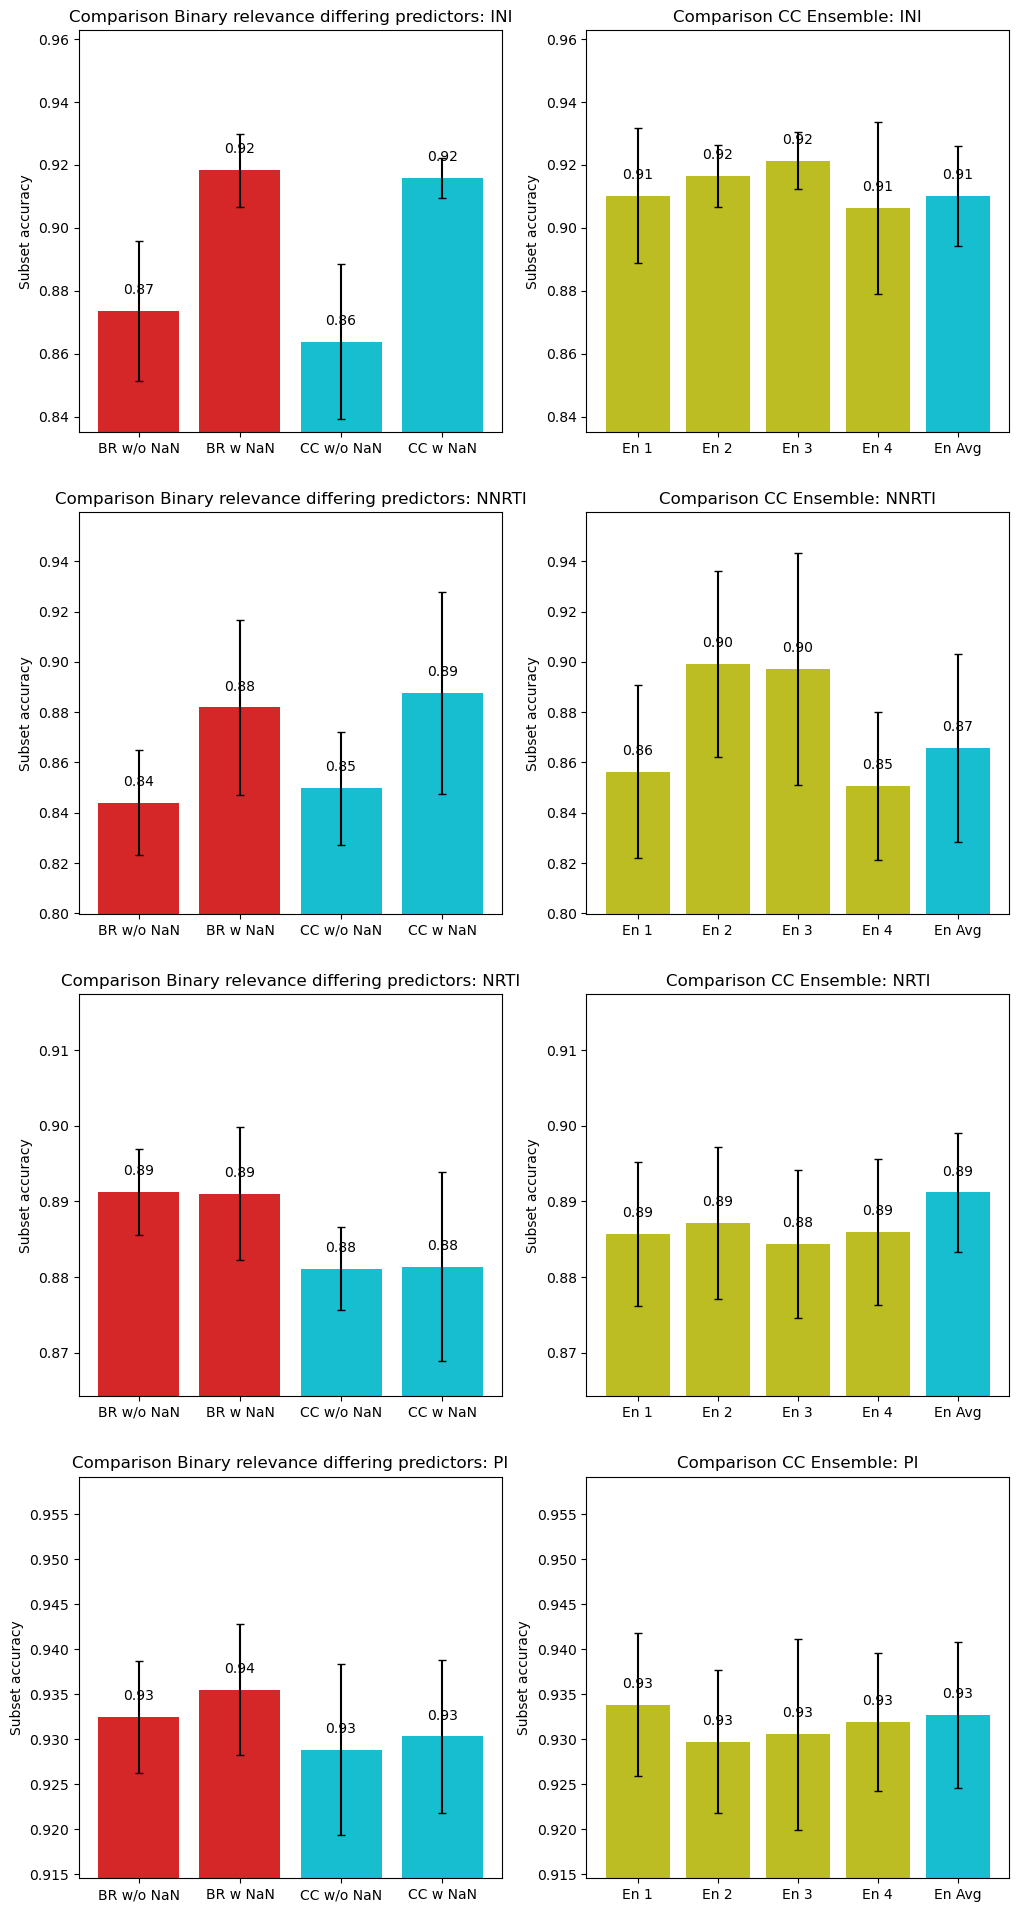

In [19]:
drop_na = True
metric = result_handler.exam_acc
kwargs = {}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)

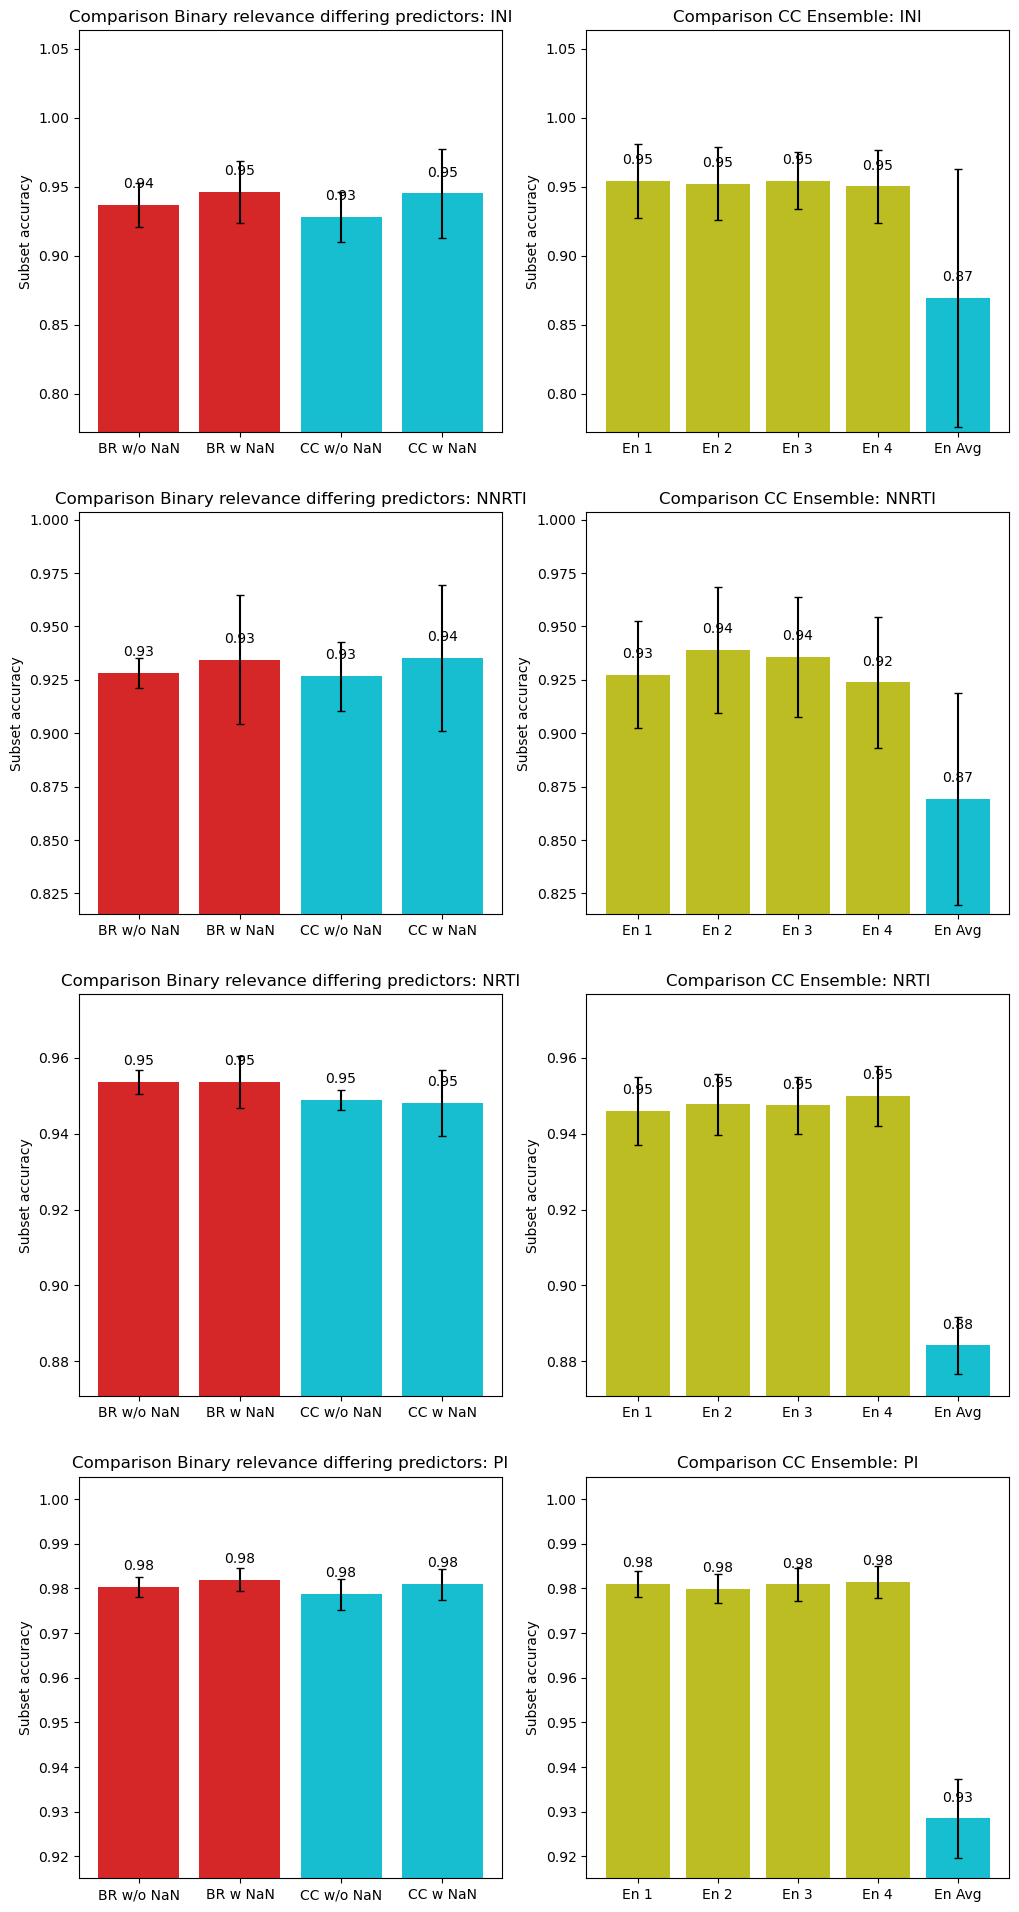

In [22]:
files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble_probabilities/"

drop_na = True
metric = roc_auc_score
kwargs = {"average":"macro"}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)

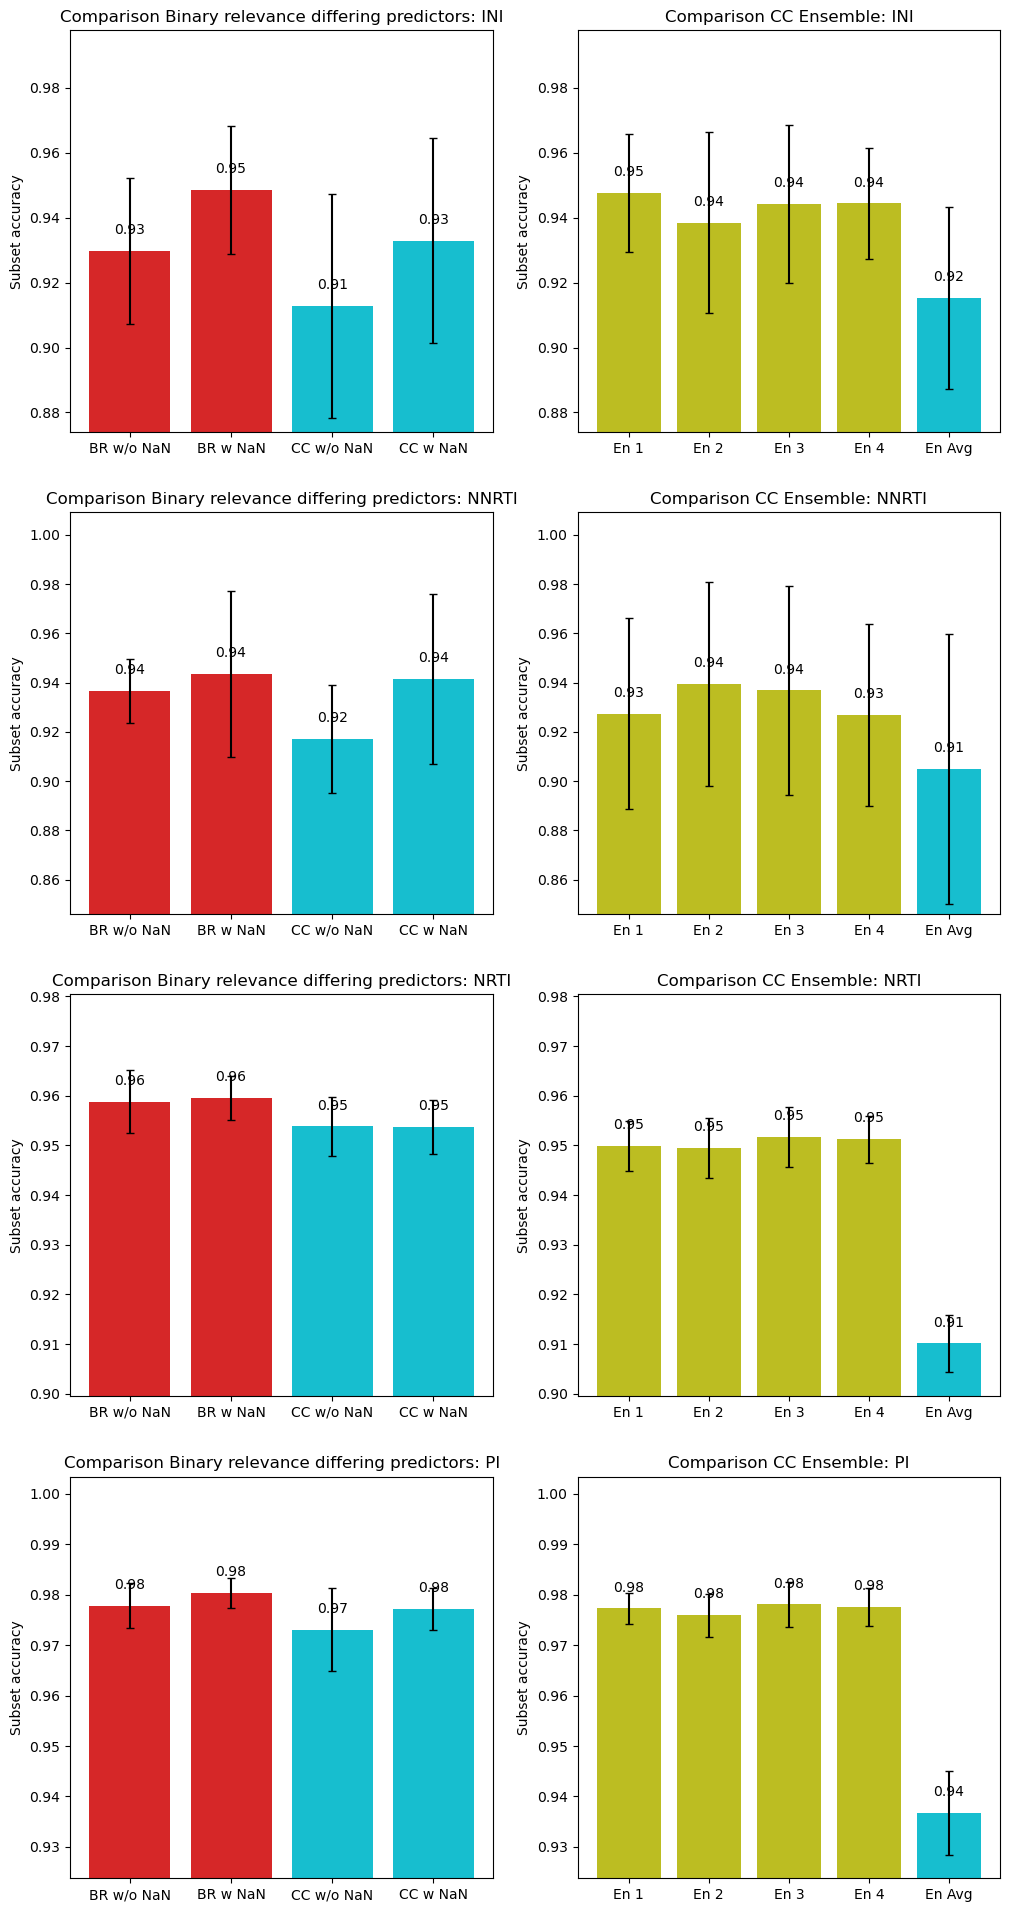

In [23]:
files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble_probabilities/"

drop_na = True
metric = result_handler.prc_auc_score
kwargs = {"multiclass":"ovr"}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)

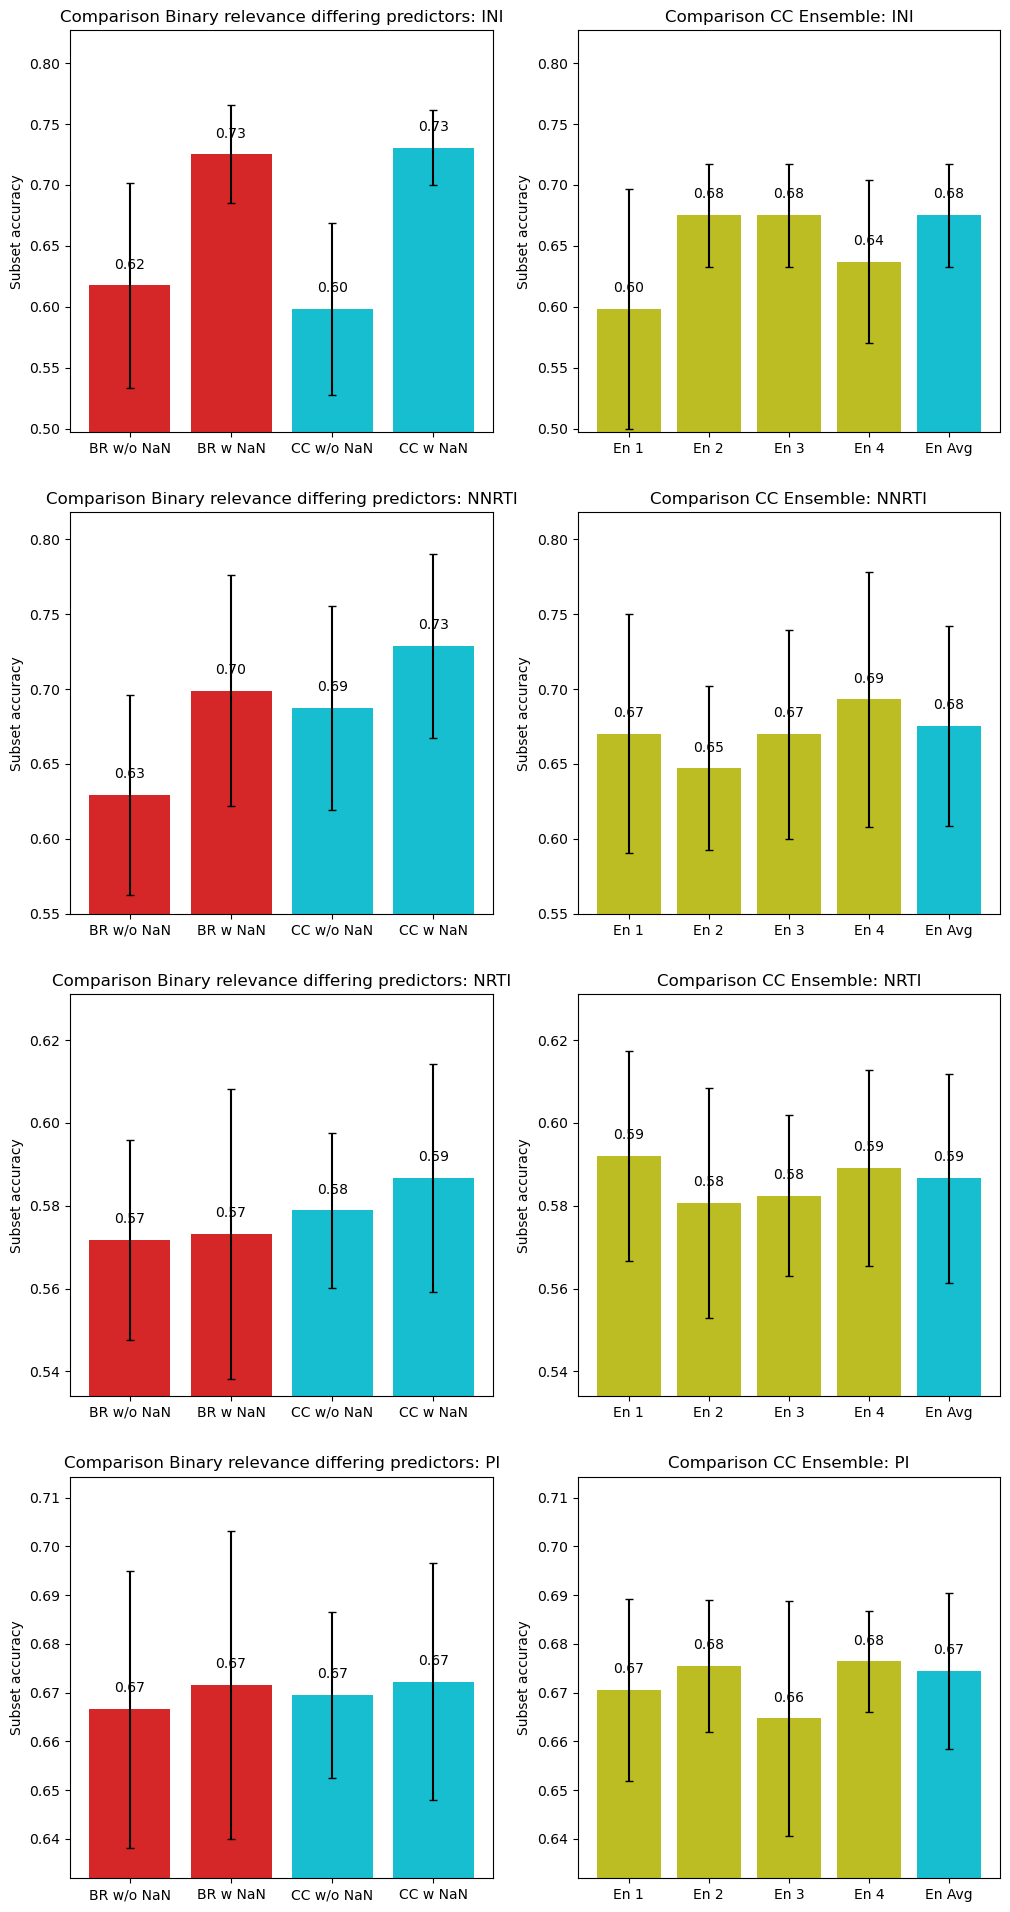

In [24]:
#ensemble trained without NaNs

files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble_wo_NaN/"

drop_na = True
metric = result_handler.subset_acc
kwargs = {"nan_mode":"ignore"}

cc_ensemble_stat(files, filename, drop_na, metric, kwargs)

## Usage of label information improves prediction